# 1D On-Site Hubbard Magnetic Mean-Field SCF

This example uses an on-site Hubbard interaction in a collinear magnetic mean-field approximation. The two spin channels are treated as two coupled spinless Hamiltonians:

`H_up = H0 + U * diag(n_down - 1/2)`

`H_dn = H0 + U * diag(n_up - 1/2)`

In [38]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS

include("../src/TensorBinding.jl")
using .TensorBinding

## 1. Non-interacting chain

In [ ]:
L = 4
t = 1.0
H_spinless = TensorBinding.get_Hamiltonian("chain_1d", t; L=L, scale=3.5)
H0 = deepcopy(H_spinless)
TensorBinding.add_spin!(H0)

println(H0)


## 2. Staggered magnetic initial guess

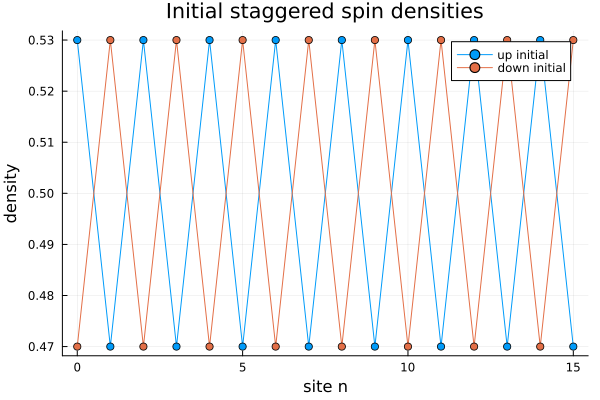

In [14]:
U = 2.0
rho_up0, rho_dn0 = TensorBinding.scf_staggered_magnetic_initial(
    H0;
    amplitude=0.03,
    background=0.5,
)

rho_up0_vals = [TensorBinding.scf_eval_profile_mps(rho_up0, n) for n in 0:H0.N-1]
rho_dn0_vals = [TensorBinding.scf_eval_profile_mps(rho_dn0, n) for n in 0:H0.N-1]

plot(0:H0.N-1, [rho_up0_vals rho_dn0_vals];
     label=["up initial" "down initial"],
     marker=:circle,
     xlabel="site n",
     ylabel="density",
     title="Initial staggered spin densities")

## 3. Run magnetic SCF

The density matrix is computed with SP2 purification. `scale` should bound the mean-field spectrum reasonably well.

In [ ]:
result = TensorBinding.scf_magnetic_hubbard(
    H0,
    U;
    initial_up=rho_up0,
    initial_dn=rho_dn0,
    background=0.5,
    density_method=:mcweeny,
    Nel_up=H0.N ÷ 2,
    Nel_dn=H0.N ÷ 2,
    scale=4.5,
    max_scf_iter=56,
    purif_maxiter=30,
    purif_tol=1e-5,
    scf_tol=1e-3,
    mix=0.25,
    maxdim=90,
    cutoff=1e-8,
    verbose=true,
)

println("converged = ", result.converged)
println("iterations = ", result.iterations)
println("final RMS = ", result.rms_error)


## 4. Magnetization and convergence

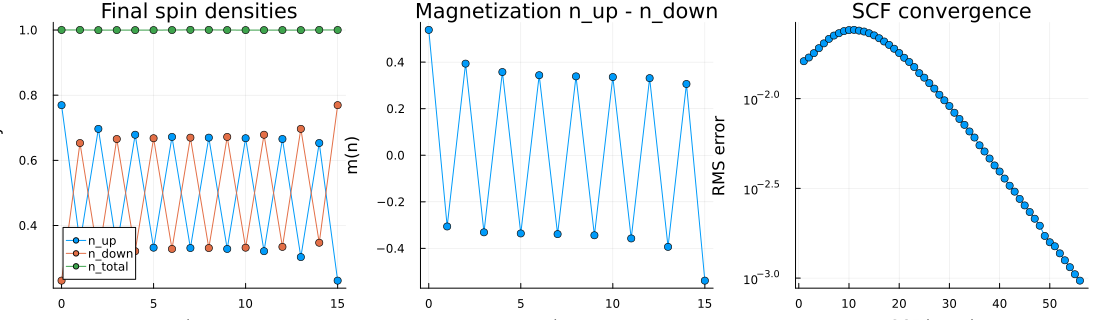

In [10]:
rho_up = [TensorBinding.scf_eval_profile_mps(result.rho_up, n) for n in 0:H0.N-1]
rho_dn = [TensorBinding.scf_eval_profile_mps(result.rho_dn, n) for n in 0:H0.N-1]
mag = rho_up .- rho_dn
charge = rho_up .+ rho_dn
errs = [h.rms_error for h in result.history]

p1 = plot(0:H0.N-1, [rho_up rho_dn charge];
    label=["n_up" "n_down" "n_total"],
    marker=:circle,
    xlabel="site n",
    ylabel="density",
    title="Final spin densities",
)

p2 = plot(0:H0.N-1, mag;
    marker=:circle,
    xlabel="site n",
    ylabel="m(n)",
    title="Magnetization n_up - n_down",
    legend=false,
)

p3 = plot(1:length(errs), errs;
    marker=:circle,
    yscale=:log10,
    xlabel="SCF iteration",
    ylabel="RMS error",
    title="SCF convergence",
    legend=false,
)

plot(p1, p2, p3; layout=(1,3), size=(1100,320))